# 4.2.2. BÀI LÀM MẪU: XÁC ĐỊNH LUẬT KẾT HỢP (DATA ONLINE RETAIL)

**Mục tiêu:**
Áp dụng giải thuật Apriori để tìm ra các luật kết hợp mua hàng từ bộ dữ liệu thực tế "Online Retail". Bài toán đặt ra là: *"Khách hàng mua sản phẩm A thường sẽ mua kèm sản phẩm B nào?"*

**Quy trình thực hiện:**
1.  Đọc và làm sạch dữ liệu (Data Cleaning).
2.  Chuyển đổi dữ liệu về dạng Basket (One-hot Encoding).
3.  Tìm tập phổ biến (Frequent Itemsets).
4.  Trích xuất luật kết hợp (Association Rules).
5.  Trực quan hóa kết quả.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
import warnings

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# 1. Đọc dữ liệu
# Lưu ý: Tên file dựa trên file bạn vừa upload
try:
    df = pd.read_excel('Online Retail.xlsx')
    print(" Đã tải dữ liệu thành công!")
    print(f"Kích thước ban đầu: {df.shape}")
except FileNotFoundError:
    print(" Không tìm thấy file. Vui lòng kiểm tra lại tên file.")

# 2. Làm sạch dữ liệu (Data Cleaning)
# Loại bỏ các dòng không có số hóa đơn
df.dropna(axis=0, subset=['InvoiceNo'], inplace=True)

# Chuyển đổi InvoiceNo sang dạng chuỗi
df['InvoiceNo'] = df['InvoiceNo'].astype('str')

# Loại bỏ các giao dịch bị hủy (InvoiceNo bắt đầu bằng chữ 'C')
df = df[~df['InvoiceNo'].str.contains('C')]

# Xóa các khoảng trắng thừa trong mô tả sản phẩm
df['Description'] = df['Description'].str.strip()

print(f"Kích thước sau khi làm sạch: {df.shape}")
df.head()

 Đã tải dữ liệu thành công!
Kích thước ban đầu: (541909, 8)
Kích thước sau khi làm sạch: (532621, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Bước 2: Chuẩn bị dữ liệu giao dịch (Basket Format)

Để chạy thuật toán Apriori, chúng ta cần chuyển đổi dữ liệu từ dạng "Dòng chi tiết" (Transactional Format) sang dạng "Ma trận nhị phân" (Basket Format):
- **Dòng (Index):** Mã hóa đơn (InvoiceNo).
- **Cột (Columns):** Tên sản phẩm (Description).
- **Giá trị:** 1 (Có mua) hoặc 0 (Không mua).

*Lưu ý: Để giảm tải khối lượng tính toán và tăng độ chính xác của luật, trong bài mẫu này chúng ta sẽ lọc riêng dữ liệu của quốc gia **"France"** (Pháp) để phân tích.*

In [2]:
# Lọc dữ liệu nước Pháp
basket = (df[df['Country'] == "France"]
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# Hàm mã hóa nhị phân (One-hot encoding)
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

# Áp dụng mã hóa
basket_sets = basket.applymap(encode_units)

# Loại bỏ cột 'POSTAGE' (Phí bưu điện) vì nó không phải là hàng hóa
if 'POSTAGE' in basket_sets.columns:
    basket_sets.drop('POSTAGE', inplace=True, axis=1)

print(" Đã chuyển đổi sang dạng Basket!")
print(f"Kích thước ma trận giỏ hàng: {basket_sets.shape}")
basket_sets.head(3)

 Đã chuyển đổi sang dạng Basket!
Kích thước ma trận giỏ hàng: (392, 1562)


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 EGG HOUSE PAINTED WOOD,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE WOODLAND,...,WRAP VINTAGE PETALS DESIGN,YELLOW COAT RACK PARIS FASHION,YELLOW GIANT GARDEN THERMOMETER,YELLOW SHARK HELICOPTER,ZINC STAR T-LIGHT HOLDER,ZINC FOLKART SLEIGH BELLS,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536370,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536852,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536974,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Bước 3: Xác định Tập phổ biến & Luật kết hợp

Sử dụng thư viện `mlxtend` để thực hiện:
1.  **Apriori:** Tìm các nhóm sản phẩm xuất hiện cùng nhau với tần suất tối thiểu (`min_support`).
2.  **Association Rules:** Sinh luật dựa trên độ tin cậy (`confidence`) hoặc độ nâng (`lift`).

In [3]:
# 1. Tìm tập phổ biến (Frequent Itemsets)
# min_support = 0.07: Sản phẩm phải xuất hiện trong ít nhất 7% số đơn hàng
frequent_itemsets = apriori(basket_sets, min_support=0.07, use_colnames=True)

print(f"Tìm thấy {len(frequent_itemsets)} tập phổ biến.")

# 2. Sinh luật kết hợp (Association Rules)
# Case 1 (Theo PDF): Metric = "confidence", ngưỡng = 0.6 (60%)
rules_conf = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

print(f"Tìm thấy {len(rules_conf)} luật thỏa mãn Confidence >= 0.6")

# Hiển thị 6 luật đầu tiên (Giống PDF trang 63)
display(rules_conf[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(6))

Tìm thấy 51 tập phổ biến.
Tìm thấy 23 luật thỏa mãn Confidence >= 0.6


,antecedents,consequents,support,confidence,lift
0,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE PINK),0.073980,0.763158,7.478947
1,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.073980,0.725000,7.478947
2,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.079082,0.837838,8.642959
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.079082,0.815789,8.642959
4,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE PINK),0.073980,0.783784,7.681081
5,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED),0.073980,0.725000,7.681081


### Nhận xét Case 1 (Confidence):
Bảng trên liệt kê các luật có độ tin cậy cao. Ví dụ, nếu khách mua `ALARM CLOCK BAKELIKE GREEN` thì 83% khả năng họ cũng sẽ mua `ALARM CLOCK BAKELIKE RED`.

## Bước 4: Mở rộng phân tích với chỉ số Lift

Trong tài liệu (trang 63), có đề cập đến `Case 2` sử dụng metric là `lift`.
* **Lift > 1:** Cho thấy mối quan hệ tương quan dương (sản phẩm A thúc đẩy việc mua sản phẩm B).
* *Lưu ý:* Tài liệu ghi `min_threshold=50`, tuy nhiên với bộ dữ liệu thực tế này, Lift thường chỉ dao động từ 1 đến 10. Để ra kết quả ý nghĩa, chúng ta sẽ chọn `min_threshold=1`.

In [4]:
# Case 2: Metric = "lift", ngưỡng = 1
rules_lift = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

print(f"Tìm thấy {len(rules_lift)} luật thỏa mãn Lift >= 1")
print(f"Số lượng luật (Shape): {rules_lift.shape[0]}")

# Sắp xếp theo Lift giảm dần để xem những luật mạnh nhất
display(rules_lift[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
        .sort_values(by='lift', ascending=False).head(6))

Tìm thấy 26 luật thỏa mãn Lift >= 1
Số lượng luật (Shape): 26


,antecedents,consequents,support,confidence,lift
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.079082,0.815789,8.642959
2,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.079082,0.837838,8.642959
4,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE PINK),0.073980,0.783784,7.681081
5,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED),0.073980,0.725000,7.681081
25,(SET/6 RED SPOTTY PAPER PLATES),"(SET/6 RED SPOTTY PAPER CUPS, SET/20 RED RETRO...",0.099490,0.780000,7.644000
20,"(SET/6 RED SPOTTY PAPER CUPS, SET/20 RED RETRO...",(SET/6 RED SPOTTY PAPER PLATES),0.099490,0.975000,7.644000


## Bước 5: Trực quan hóa kết quả

Thực hiện vẽ các biểu đồ theo yêu cầu của Hình 4.1 và 4.2 trong tài liệu tham khảo.

### 5.1. Mối quan hệ giữa Support và Confidence

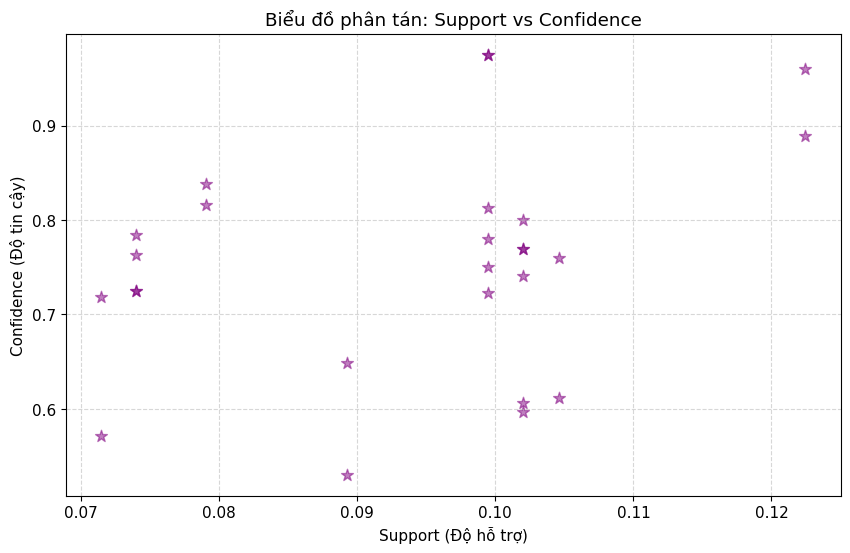

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(rules_lift['support'], rules_lift['confidence'], alpha=0.5, marker="*", s=80, color='purple')
plt.xlabel("Support (Độ hỗ trợ)")
plt.ylabel("Confidence (Độ tin cậy)")
plt.title("Biểu đồ phân tán: Support vs Confidence")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 5.2. Phân phối tần suất của độ tin cậy (Confidence)
Biểu đồ Histogram giúp chúng ta biết được đa số các luật tìm được có độ tin cậy nằm trong khoảng nào.

<Figure size 1000x600 with 0 Axes>

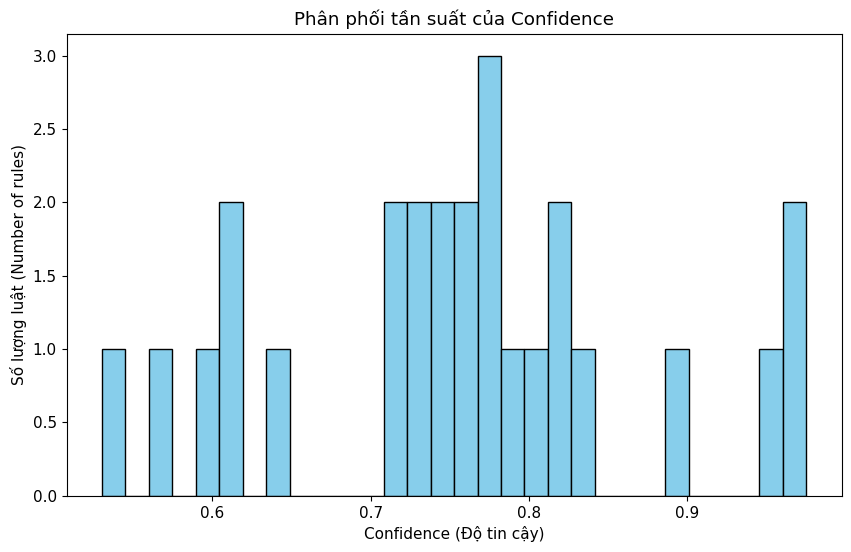

In [6]:
plt.figure(figsize=(10, 6))
rules_lift.hist("confidence", grid=False, bins=30, color='skyblue', edgecolor='black', figsize=(10,6))
plt.xlabel("Confidence (Độ tin cậy)")
plt.ylabel("Số lượng luật (Number of rules)")
plt.title("Phân phối tần suất của Confidence")
plt.show()

# KẾT LUẬN BÀI TẬP MẪU

Từ bộ dữ liệu Online Retail (thị trường Pháp), chúng ta đã tìm ra các quy luật mua hàng thú vị:
1.  **Bộ sản phẩm "SET/BOX":** Khách hàng có xu hướng mua trọn bộ sưu tập. Ví dụ: Mua `PLASTERS IN TIN CIRCUS PARADE` thì rất hay mua kèm `PLASTERS IN TIN SPACEBOY`.
2.  **Độ mạnh của luật:** Đa số các luật tìm được có độ tin cậy (Confidence) rất cao (> 0.8) và độ nâng (Lift) lớn hơn 1, chứng tỏ mối quan hệ giữa các sản phẩm là rất chặt chẽ chứ không phải ngẫu nhiên.